<a href="https://colab.research.google.com/github/HarryAI-6748/trendpulse-Harkirat/blob/main/task2_data_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the required libraries for data processing

In [30]:
import requests
import json
import pandas as pd

Fetching the data from REST API url and parsing the data into json followed by conversion to data frame

In [31]:
url = "https://restcountries.com/v3.1/all"
params = {"fields": "name,population,region,area,languages,borders,unMember,independent,subregion,continents"}

response = requests.get(url, params)
count_data = response.json()
df = pd.DataFrame(count_data)
df['common_name'] = df['name'].apply(lambda x: x['common'])
df['official_name'] = df['name'].apply(lambda x: x['official'])
df['languages'] = df['languages'].apply(lambda x: ', '.join(sorted(x.values())))
df

,name,languages,independent,unMember,region,subregion,borders,area,population,continents,common_name,official_name
0,"{'common': 'Ivory Coast', 'official': 'Republi...",French,True,True,Africa,Western Africa,"[BFA, GHA, GIN, LBR, MLI]",322463.0,31719275,[Africa],Ivory Coast,Republic of Côte d'Ivoire
1,"{'common': 'Italy', 'official': 'Italian Repub...","Catalan, Italian",True,True,Europe,Southern Europe,"[AUT, FRA, SMR, SVN, CHE, VAT]",301336.0,58927633,[Europe],Italy,Italian Republic
2,"{'common': 'Kyrgyzstan', 'official': 'Kyrgyz R...","Kyrgyz, Russian",True,True,Asia,Central Asia,"[CHN, KAZ, TJK, UZB]",199951.0,7281800,[Asia],Kyrgyzstan,Kyrgyz Republic
3,"{'common': 'Papua New Guinea', 'official': 'In...","English, Hiri Motu, Tok Pisin",True,True,Oceania,Melanesia,[IDN],462840.0,11781559,[Oceania],Papua New Guinea,Independent State of Papua New Guinea
4,"{'common': 'Fiji', 'official': 'Republic of Fi...","English, Fiji Hindi, Fijian",True,True,Oceania,Melanesia,[],18272.0,900869,[Oceania],Fiji,Republic of Fiji
...,...,...,...,...,...,...,...,...,...,...,...,...
245,"{'common': 'Singapore', 'official': 'Republic ...","Chinese, English, Malay, Tamil",True,True,Asia,South-Eastern Asia,[],710.0,6110200,[Asia],Singapore,Republic of Singapore
246,"{'common': 'Costa Rica', 'official': 'Republic...",Spanish,True,True,Americas,Central America,"[NIC, PAN]",51100.0,5309625,[North America],Costa Rica,Republic of Costa Rica
247,"{'common': 'Serbia', 'official': 'Republic of ...",Serbian,True,True,Europe,Southeast Europe,"[BIH, BGR, HRV, HUN, UNK, MKD, MNE, ROU]",77589.0,6567783,[Europe],Serbia,Republic of Serbia
248,"{'common': 'Poland', 'official': 'Republic of ...",Polish,True,True,Europe,Central Europe,"[BLR, CZE, DEU, LTU, RUS, SVK, UKR]",312679.0,37392000,[Europe],Poland,Republic of Poland


Checking the data frame data using df.info() method. It provides a concise, high-level summary of a DataFrame’s structure and metadata. It is primarily being used  for exploratory data analysis (EDA) to quickly assess data quality, such as identifying missing values and ensuring correct data types

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           250 non-null    object 
 1   languages      250 non-null    object 
 2   independent    250 non-null    bool   
 3   unMember       250 non-null    bool   
 4   region         250 non-null    object 
 5   subregion      250 non-null    object 
 6   borders        250 non-null    object 
 7   area           250 non-null    float64
 8   population     250 non-null    int64  
 9   continents     250 non-null    object 
 10  common_name    250 non-null    object 
 11  official_name  250 non-null    object 
dtypes: bool(2), float64(1), int64(1), object(8)
memory usage: 20.1+ KB


Using df.describe() method to generate a statistical summary of a DataFrame's  numerical columns. It provides a quick overview of the data's central tendency, dispersion, and distribution shape.

In [33]:
df.describe()

,area,population
count,2.500000e+02,2.500000e+02
mean,6.010389e+05,3.207798e+07
std,1.912575e+06,1.319655e+08
min,4.900000e-01,0.000000e+00
25%,1.194250e+03,2.233542e+05
50%,6.492950e+04,5.279123e+06
75%,3.841505e+05,2.037166e+07
max,1.709825e+07,1.417492e+09


Using df.describe() method to generate a statistical summary of a DataFrame's all columns

In [34]:
df.describe(include = 'all')

,name,languages,independent,unMember,region,subregion,borders,area,population,continents,common_name,official_name
count,250,250,250,250,250,250,250,2.500000e+02,2.500000e+02,250,250,250
unique,250,142,2,2,6,25,159,NaN,NaN,8,250,250
top,"{'common': 'Ivory Coast', 'official': 'Republi...",English,True,True,Africa,Caribbean,[],NaN,NaN,[Africa],Ivory Coast,Republic of Côte d'Ivoire
freq,1,39,195,192,59,28,86,NaN,NaN,58,1,1
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.010389e+05,3.207798e+07,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.912575e+06,1.319655e+08,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.900000e-01,0.000000e+00,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.194250e+03,2.233542e+05,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.492950e+04,5.279123e+06,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.841505e+05,2.037166e+07,NaN,NaN,NaN


Using isnull() method, identifying the total number of misssing values per column

In [35]:
df.isnull().sum()

,0
name,0
languages,0
independent,0
unMember,0
region,0
subregion,0
borders,0
area,0
population,0
continents,0


Copying the data frame and converting it to identify the duplicated rows

In [12]:
df_temp = df.copy()
df_temp['name'] = df_temp['name'].apply(lambda x: x.get('common'))
df_temp['languages'] = df_temp['languages'].apply(lambda x: ', '.join(sorted(x.keys())))
df_temp['borders'] = df_temp['borders'].apply(lambda x: tuple(sorted(x)))
df_temp['continents'] = df_temp['continents'].apply(lambda x: tuple(sorted(x)))
duplicated_rows = df_temp.duplicated()
print(duplicated_rows)

0      False
1      False
2      False
3      False
4      False
       ...  
245    False
246    False
247    False
248    False
249    False
Length: 250, dtype: bool


Importing the required libraries for basic visualisation of data frame

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

Re-arranging the columns for better data corelation and analysis

In [38]:
df.drop(columns = ['name'], inplace = True)
df = df[['common_name', 'continents', 'region', 'subregion','independent','unMember','languages','area','population','borders']]
df

,common_name,continents,region,subregion,independent,unMember,languages,area,population,borders
0,Ivory Coast,[Africa],Africa,Western Africa,True,True,French,322463.0,31719275,"[BFA, GHA, GIN, LBR, MLI]"
1,Italy,[Europe],Europe,Southern Europe,True,True,"Catalan, Italian",301336.0,58927633,"[AUT, FRA, SMR, SVN, CHE, VAT]"
2,Kyrgyzstan,[Asia],Asia,Central Asia,True,True,"Kyrgyz, Russian",199951.0,7281800,"[CHN, KAZ, TJK, UZB]"
3,Papua New Guinea,[Oceania],Oceania,Melanesia,True,True,"English, Hiri Motu, Tok Pisin",462840.0,11781559,[IDN]
4,Fiji,[Oceania],Oceania,Melanesia,True,True,"English, Fiji Hindi, Fijian",18272.0,900869,[]
...,...,...,...,...,...,...,...,...,...,...
245,Singapore,[Asia],Asia,South-Eastern Asia,True,True,"Chinese, English, Malay, Tamil",710.0,6110200,[]
246,Costa Rica,[North America],Americas,Central America,True,True,Spanish,51100.0,5309625,"[NIC, PAN]"
247,Serbia,[Europe],Europe,Southeast Europe,True,True,Serbian,77589.0,6567783,"[BIH, BGR, HRV, HUN, UNK, MKD, MNE, ROU]"
248,Poland,[Europe],Europe,Central Europe,True,True,Polish,312679.0,37392000,"[BLR, CZE, DEU, LTU, RUS, SVK, UKR]"


Identifying Outliers in the data

<Axes: xlabel='area', ylabel='population'>

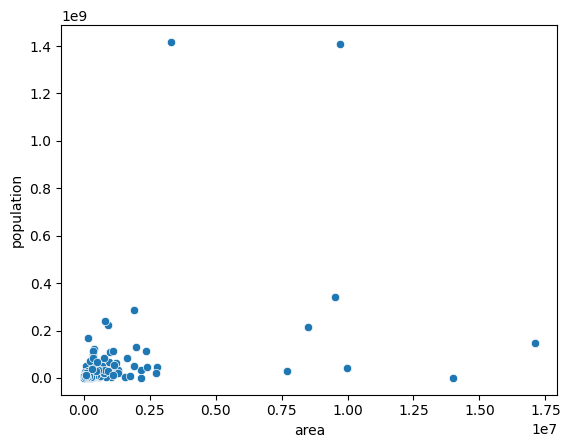

In [39]:
sns.scatterplot(data=df, x='area', y='population', hue=None, style=None, size=None, palette=None)
# This plot describes the relation between area and population.

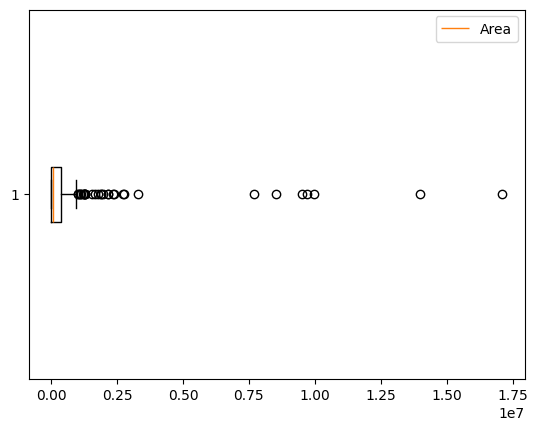

In [50]:
plt.boxplot(df['area'], vert = False, label='Area')
#plt.boxplot(df['population'], vert = False, label='Population')
plt.legend()
# This plot describes the outliers in Area of individual countries.

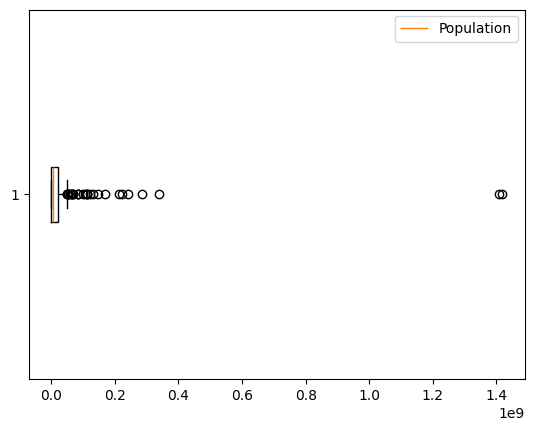

In [51]:
plt.boxplot(df['population'], vert=False, label='Population')
plt.legend()
# This plot describes the outliers in Population.